# Inflation Burdern by Wealth Percentile

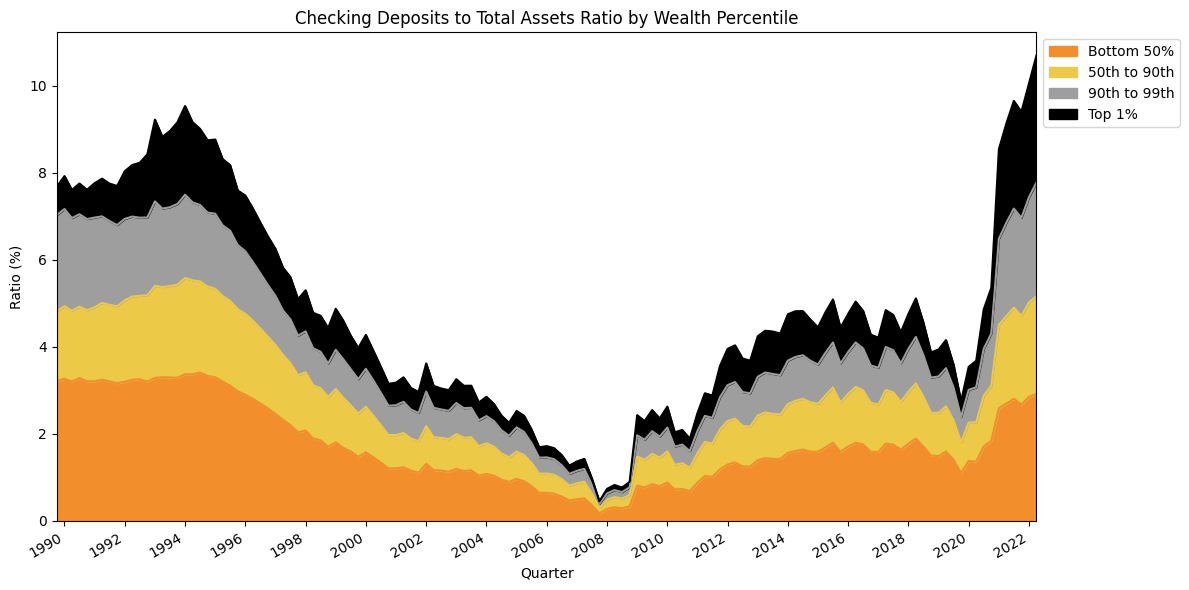

In [1]:
import pandas as pd
import matplotlib.pyplot as plt


def fred_series(series_id: str) -> pd.DataFrame:
    url = f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={series_id}"
    df = pd.read_csv(url)
    # Normalize column names; some responses include whitespace or alternate labels.
    df.columns = [str(c).strip().lstrip("﻿") for c in df.columns]
    date_col = "DATE" if "DATE" in df.columns else df.columns[0]
    df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
    df = df.set_index(date_col)
    # Standardize the data column name to the series id and coerce missing values
    if series_id in df.columns:
        df = df.rename(columns={series_id: series_id})
    else:
        data_col = df.columns[0]
        df = df.rename(columns={data_col: series_id})
    df[series_id] = pd.to_numeric(df[series_id], errors="coerce")
    return df


# Fetch series as individual dataframes
WFRBSB50194 = fred_series("WFRBSB50194")
WFRBSN40167 = fred_series("WFRBSN40167")
WFRBSN09140 = fred_series("WFRBSN09140")
WFRBST01113 = fred_series("WFRBST01113")
WFRBSB50189 = fred_series("WFRBSB50189")
WFRBSN40162 = fred_series("WFRBSN40162")
WFRBSN09135 = fred_series("WFRBSN09135")
WFRBST01108 = fred_series("WFRBST01108")
BOGZ1FL193020005Q = fred_series("BOGZ1FL193020005Q")
BOGZ1FL192000005A = fred_series("BOGZ1FL192000005A")


def to_quarterly(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out.index = out.index.to_period("Q")
    return out


def to_annual(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out.index = out.index.to_period("Y")
    return out


# Convert to period indexes
WFRBSB50194 = to_quarterly(WFRBSB50194)
WFRBSN40167 = to_quarterly(WFRBSN40167)
WFRBSN09140 = to_quarterly(WFRBSN09140)
WFRBST01113 = to_quarterly(WFRBST01113)
WFRBSB50189 = to_quarterly(WFRBSB50189)
WFRBSN40162 = to_quarterly(WFRBSN40162)
WFRBSN09135 = to_quarterly(WFRBSN09135)
WFRBST01108 = to_quarterly(WFRBST01108)

BOGZ1FL193020005Q = to_quarterly(BOGZ1FL193020005Q)
BOGZ1FL193020005Q = BOGZ1FL193020005Q[
    BOGZ1FL193020005Q.index >= pd.Period("1989Q3", freq="Q")
]

BOGZ1FL192000005A = to_annual(BOGZ1FL192000005A)
BOGZ1FL192000005A = BOGZ1FL192000005A[
    BOGZ1FL192000005A.index >= pd.Period("1989", freq="Y")
]

# Reindex annual data to Q3 and interpolate to quarterly frequency
annual = BOGZ1FL192000005A.copy()
annual.index = annual.index.year
annual_q3 = annual.copy()
annual_q3.index = pd.PeriodIndex([f"{y}Q3" for y in annual.index], freq="Q")
annual_q3 = annual_q3.sort_index()

full_quarters = pd.period_range(
    start=annual_q3.index.min(), end=annual_q3.index.max(), freq="Q"
)
BOGZ1FL192000005A_mod = annual_q3.reindex(full_quarters)
BOGZ1FL192000005A_mod = BOGZ1FL192000005A_mod.interpolate(method="linear")

# Build cashRatios dataframe
combined = pd.concat(
    [
        WFRBSB50194,
        WFRBSN40167,
        WFRBSN09140,
        WFRBST01113,
        WFRBSB50189,
        WFRBSN40162,
        WFRBSN09135,
        WFRBST01108,
        BOGZ1FL193020005Q,
        BOGZ1FL192000005A_mod,
    ],
    axis=1,
).dropna()

cashRatios = pd.DataFrame(index=combined.index)

cashRatios["Bottom 50%"] = (
    combined["WFRBSB50194"] * combined["BOGZ1FL193020005Q"]
) / (combined["WFRBSB50189"] * combined["BOGZ1FL192000005A"])

cashRatios["50th to 90th"] = (
    combined["WFRBSN40167"] * combined["BOGZ1FL193020005Q"]
) / (combined["WFRBSN40162"] * combined["BOGZ1FL192000005A"])

cashRatios["90th to 99th"] = (
    combined["WFRBSN09140"] * combined["BOGZ1FL193020005Q"]
) / (combined["WFRBSN09135"] * combined["BOGZ1FL192000005A"])

cashRatios["Top 1%"] = (
    combined["WFRBST01113"] * combined["BOGZ1FL193020005Q"]
) / (combined["WFRBST01108"] * combined["BOGZ1FL192000005A"])

# Express as percent
cashRatios = cashRatios * 100

# Stacked area chart
cashRatios_plot = cashRatios.copy()
cashRatios_plot.index = cashRatios_plot.index.to_timestamp(how="end")

# Ensure column order matches desired color order
cashRatios_plot = cashRatios_plot[["Bottom 50%", "50th to 90th", "90th to 99th", "Top 1%"]]

colors = ["#F28E2B", "#EDC948", "#9E9E9E", "#000000"]
ax = cashRatios_plot.plot.area(stacked=True, figsize=(12, 6), color=colors)
ax.set_title("Checking Deposits to Total Assets Ratio by Wealth Percentile")
ax.set_xlabel("Quarter")
ax.set_ylabel("Ratio (%)")
ax.legend(loc="upper left", bbox_to_anchor=(1.0, 1.0))

# Tighten x-axis to data range and increase tick density to every 2 years
ax.set_xlim(cashRatios_plot.index.min(), cashRatios_plot.index.max())
import matplotlib.dates as mdates
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()
